# 01 · Quick look at one take

Raw waveforms first, before any processing, because a mis-wired or silent channel, a clipped
channel or a knock on the bench is obvious in the raw samples and invisible in a summary number.
Then process that one take (a single streaming pass, cached) and look at its spectrogram.

In [1]:
# ==== YOUR SETTINGS ====
CONFIG = "../config/demo.yaml"
TAKE = "DEMO_002"            # a take name from notebook 00
T0, T1 = 39.5, 41.5          # a short window [s] for the raw waveform view

In [2]:
# ---- standard setup (same in every notebook) ----
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import zoom_acoustics as za
from zoom_acoustics import plots as zp, dsp

cfg = za.load_config(CONFIG)
print("config   :", cfg.config_file)
print("data_dir :", cfg.data_dir)
print("cache_dir:", cfg.cache_dir)
print("figures  :", cfg.figures_dir)

config   : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/config/demo.yaml
data_dir : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/audio
cache_dir: /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/cache
figures  : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures


In [3]:
takes = za.discover_takes(cfg.data_dir, recursive=cfg.recursive, pattern=cfg.file_pattern)
take = za.find_take(takes, TAKE)
take.describe()

{'take': 'DEMO_002',
 'start': datetime.datetime(2026, 10, 1, 10, 2),
 'duration_s': 180.0,
 'sr': 48000,
 'n_channels': 4,
 'channels': '1,2,3,4',
 'tracks': 'Hyd_A,Hyd_B,Contact,AirMic',
 'n_parts': 1,
 'n_files': 1,
 'subtype': 'FLOAT',
 'size_GB': 0.138}

## Raw waveforms

Units are the recorded sample value (FS = digital full scale). Files are 32-bit float, so values
above 1 are legal and are **not** clipping. `highpass_hz` removes rumble so small transients are visible.

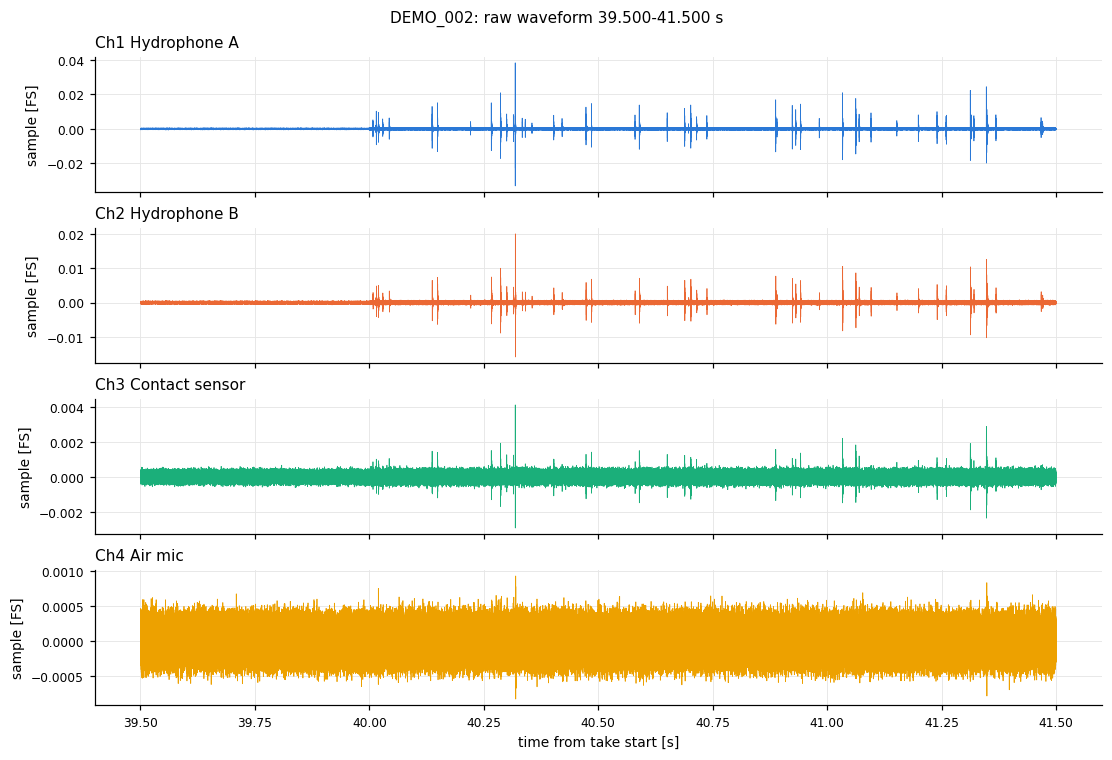

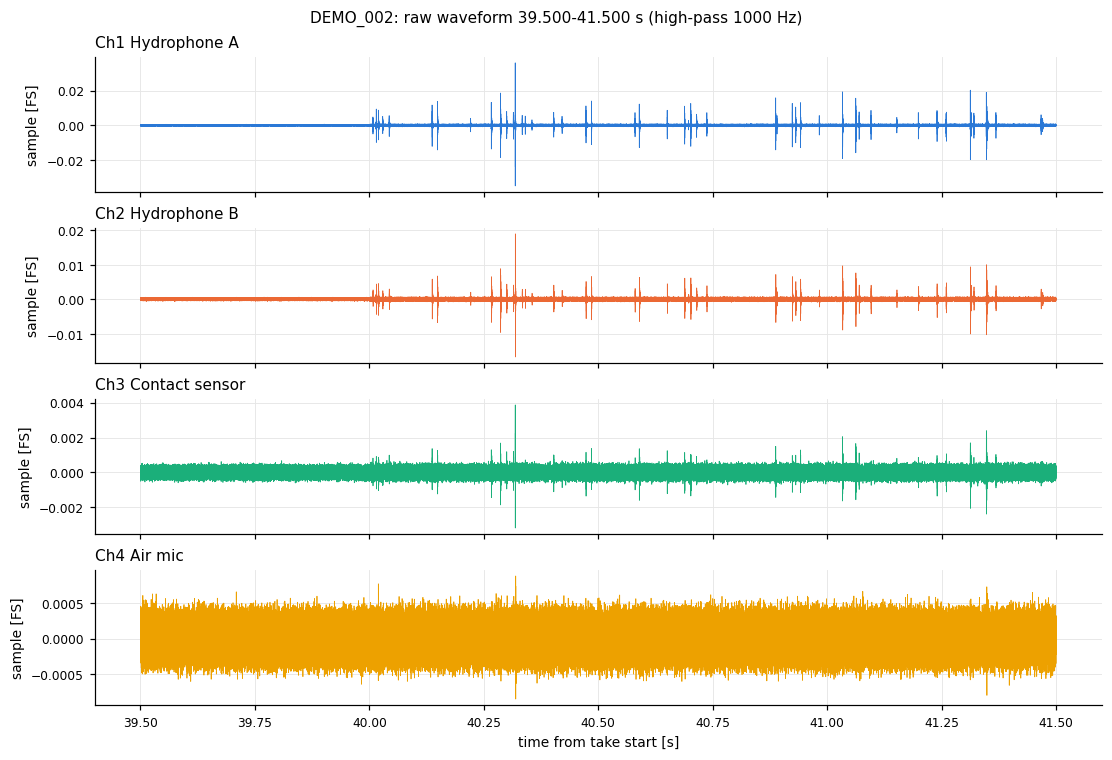

In [4]:
fig = zp.plot_waveforms(take, T0, T1, cfg=cfg)
fig = zp.plot_waveforms(take, T0, T1, cfg=cfg, highpass_hz=1000)

## Process this take

This reads the files once, block by block, and writes the feature bundle to `cache_dir/<take>/`.
Running it again does nothing unless the files or the settings changed.

In [5]:
za.process_take(take, cfg)
f = za.load_features(cfg, TAKE)
print("channels:", f.channels, " bands:", f.bands)
print("peak |sample| per channel:", np.round(f.meta["peak_abs"], 4))
print("samples with |x| > 1 (legal in float files, check if unexpected):", f.meta["n_samples_over_unity"])

DEMO_002: cached bundle is up to date (/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/cache/DEMO_002)
channels: [1, 2, 3, 4]  bands: ['low', 'audio', 'rig', 'broadband']
peak |sample| per channel: [0.3798 0.38   0.3796 0.3798]
samples with |x| > 1 (legal in float files, check if unexpected): [0, 0, 0, 0]


## Full range, then zoom

The top panel is the whole take. The boxes are zooms chosen from the analysis (quiet baseline, onset,
loudest 30 s, a significant glide, the strongest single event). The event zoom is recomputed from the
**raw audio**, because a 0.25 s spectrogram frame is longer than the event. Grey gaps are masked time
(chirps). Change `CH` to look at another sensor.

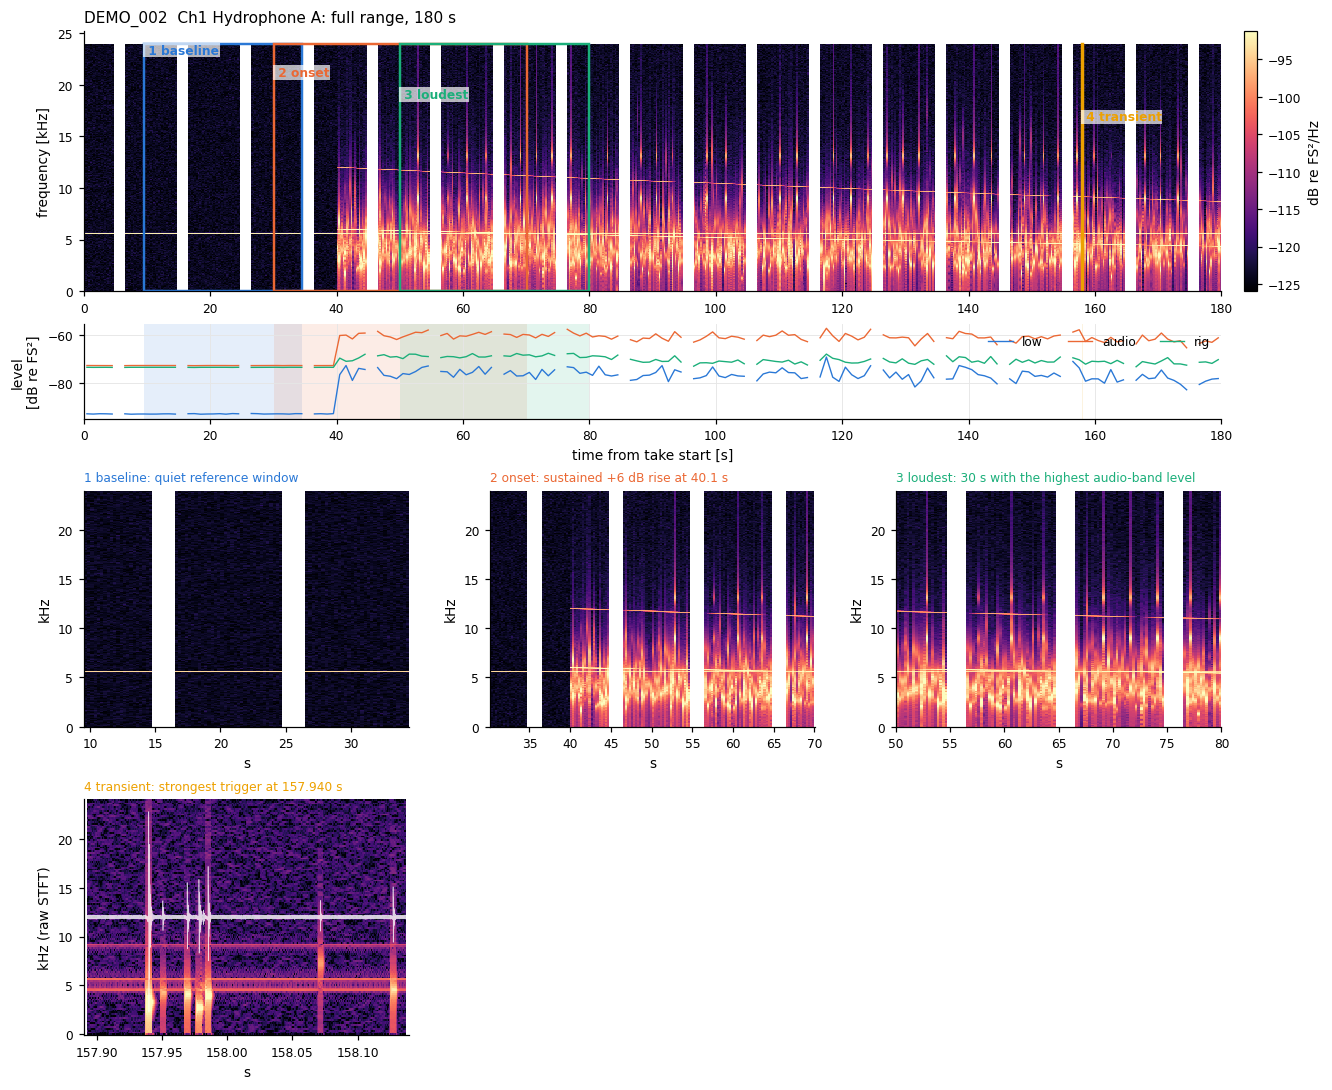

In [6]:
CH = f.channels[0]
zooms = za.views.suggest_zooms(f, CH, baseline=(T0 - 30, T0 - 5) if T0 > 35 else (1, 10),
                               fmax=min(24000, f.sr / 2))
fig = za.views.plot_overview_zoom(f, CH, zooms, take=take, fmax=min(24000, f.sr / 2))

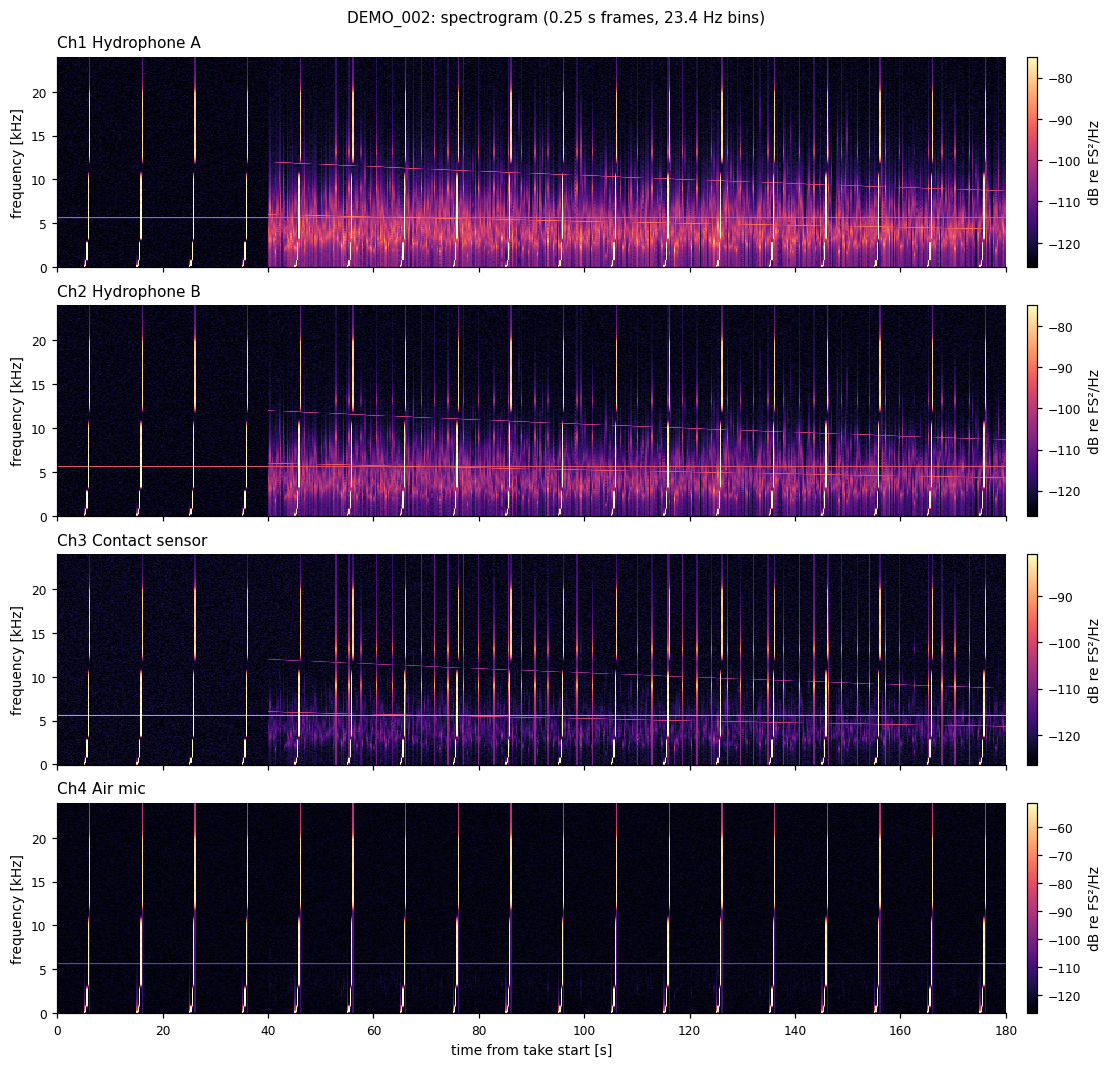

In [7]:
fig = zp.plot_spectrogram(f, fmax=min(24000, f.sr / 2))

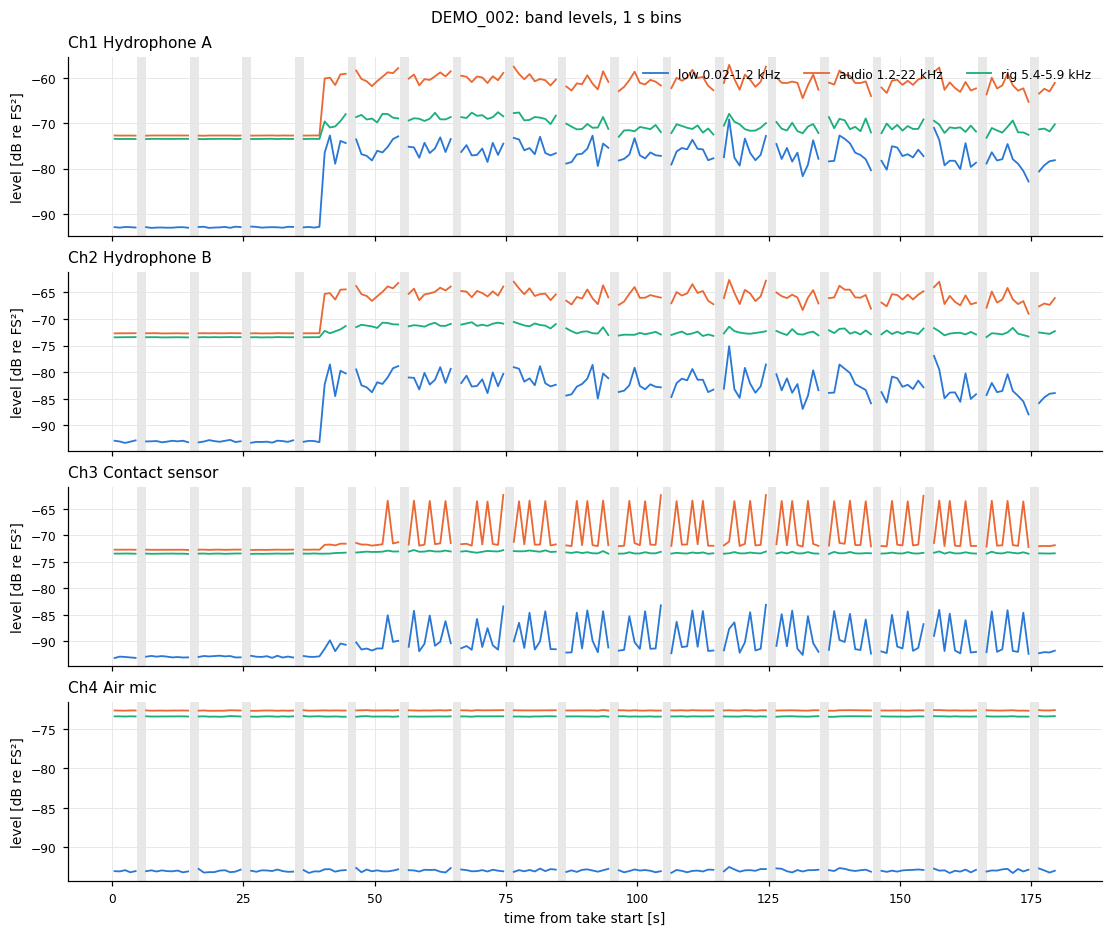

In [8]:
fig = zp.plot_levels(f, bands=[b for b in ("low", "audio", "rig") if b in f.bands], dt=1.0)

**Look for:** channels that never change (disconnected?), steps where something was moved, periodic
spikes (active chirps: mask them, see notebook 03), and the reaction onset.